In [1]:
import requests

# object_id = 108594
# object_id = 48562
# object_id = 195792
# object_id = 123684
# object_id = 130667
# object_id = 102598
# object_id = 67142
# object_id = 13823
# object_id = 5199
# object_id = 63908
# object_id = 542
# object_id = 966
object_id = 5032

url = "https://gisccapps.charlestoncounty.org/arcgis/rest/services/GIS_VIEWER/New_Parcel_Search/MapServer/61/query"

params = {
    "f": "json",
    "where": f"OBJECTID={object_id}",
    "outFields": "OBJECTID,PID,ACREAGE",
    "returnGeometry": "true",
}

# params = {
#     "f": "json",
#     "resultOffset": 40,
#     "resultRecordCount": 10,
#     "outFields": "OBJECTID,PID,ACREAGE",
#     "returnGeometry": "true",
# }

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()
data.keys()

dict_keys(['displayFieldName', 'fieldAliases', 'geometryType', 'spatialReference', 'fields', 'features'])

In [2]:
for feature in data["features"]:
    rings = feature["geometry"]["rings"]
    if len(rings) != 1:
        print(feature["attributes"])
        print("num_rings:", len(rings))

{'OBJECTID': 5032, 'PID': '1620000138', 'ACREAGE': 138.25}
num_rings: 2


In [3]:
data["spatialReference"]

{'wkid': 2273, 'latestWkid': 2273}

In [4]:
data

{'displayFieldName': 'PROP_ST_NAME',
 'fieldAliases': {'OBJECTID': 'OBJECTID',
  'PID': 'PID',
  'ACREAGE': 'DEEDED ACREAGE'},
 'geometryType': 'esriGeometryPolygon',
 'spatialReference': {'wkid': 2273, 'latestWkid': 2273},
 'fields': [{'name': 'OBJECTID',
   'type': 'esriFieldTypeOID',
   'alias': 'OBJECTID'},
  {'name': 'PID', 'type': 'esriFieldTypeString', 'alias': 'PID', 'length': 15},
  {'name': 'ACREAGE',
   'type': 'esriFieldTypeDouble',
   'alias': 'DEEDED ACREAGE'}],
 'features': [{'attributes': {'OBJECTID': 5032,
    'PID': '1620000138',
    'ACREAGE': 138.25},
   'geometry': {'rings': [[[2226214.2900049537, 315906.6300032586],
      [2226054.4300355017, 316003.1499789506],
      [2226105.573987052, 316089.0820301324],
      [2225987.656728551, 316178.52314180136],
      [2225844.2438465804, 316287.3030488044],
      [2225807.937896788, 316227.45420721173],
      [2225792.3784805983, 316201.80466909707],
      [2226054.4300355017, 316003.1499789506],
      [2225930.8099486977

In [5]:
feature = data["features"][0]

feature["attributes"]

{'OBJECTID': 5032, 'PID': '1620000138', 'ACREAGE': 138.25}

In [6]:
geometry = feature["geometry"]
geometry.keys()

dict_keys(['rings'])

In [7]:
len(geometry["rings"])

2

In [8]:
i, ring = next(enumerate(feature["geometry"]["rings"]))
(i, ring)

(0,
 [[2226214.2900049537, 315906.6300032586],
  [2226054.4300355017, 316003.1499789506],
  [2226105.573987052, 316089.0820301324],
  [2225987.656728551, 316178.52314180136],
  [2225844.2438465804, 316287.3030488044],
  [2225807.937896788, 316227.45420721173],
  [2225792.3784805983, 316201.80466909707],
  [2226054.4300355017, 316003.1499789506],
  [2225930.8099486977, 316081.7998826057],
  [2225778.3400606215, 316179.17001894116],
  [2225764.859944269, 316187.9199217707],
  [2225869.9451735914, 316356.75848798454],
  [2226204.8399840742, 316511.359948799],
  [2226319.450013563, 316702.23009076715],
  [2225988.570052296, 316925.0600296259],
  [2225862.1100465357, 316726.8699874878],
  [2225669.0299224705, 316488.1899854243],
  [2225538.6404949874, 316318.1505945176],
  [2225537.0599657446, 316319.0600461811],
  [2225393.7133929282, 316402.1959811747],
  [2225207.540067911, 316510.170014292],
  [2225023.9300510883, 316616.64991365373],
  [2224999.9999526143, 316577.3198797405],
  [222490

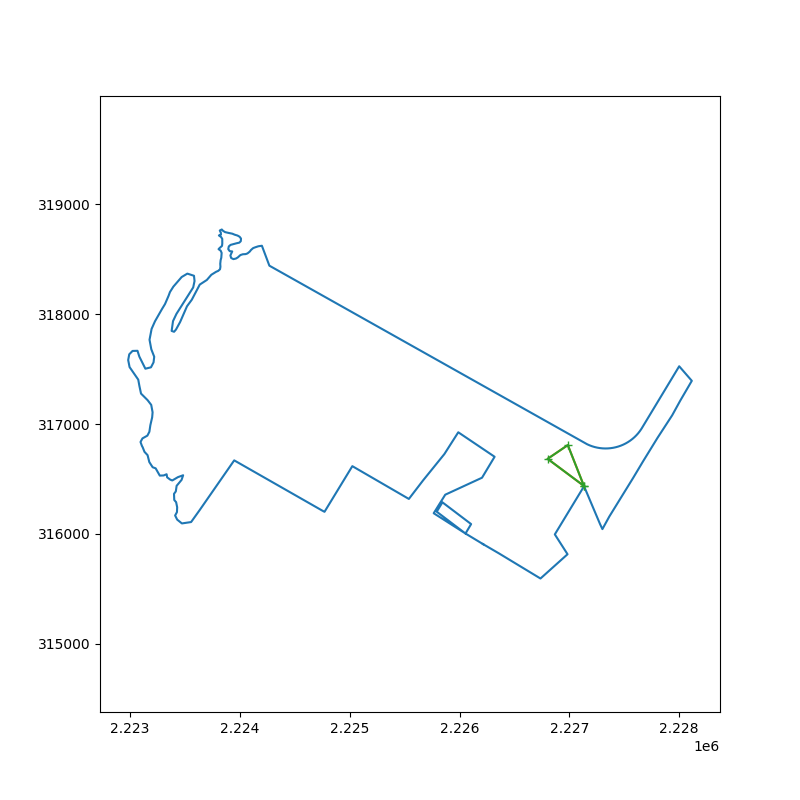

In [11]:
%matplotlib widget

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

for i, ring in enumerate(feature["geometry"]["rings"]):
    x = [p[0] for p in ring]
    y = [p[1] for p in ring]

    plt.plot(x, y, label=f"ring {i}")

plt.plot(x, y, "+-")
plt.axis("equal")
plt.savefig('pid-49--5-rings.png')
plt.show()

In [9]:
from shapely.geometry import Polygon

areas = []

for ring in feature["geometry"]["rings"]:
    areas.append(Polygon(ring).area)

area_sqft = sum(areas)
computed_acreage = area_sqft / 43_560

area_sqft, computed_acreage

(6536562.817120045, 150.05883418549232)

In [10]:
deeded_acreage = feature["attributes"]["ACREAGE"]

deeded_acreage, computed_acreage, computed_acreage - deeded_acreage

(138.25, 150.05883418549232, 11.808834185492316)

In [11]:
from shapely.geometry import Polygon
from shapely.validation import explain_validity

for i, ring in enumerate(feature["geometry"]["rings"]):
    polygon = Polygon(ring)
    print(i, polygon.is_valid, explain_validity(polygon), polygon.area)

0 False Ring Self-intersection[2226054.4300355 316003.149978951] 6493146.497436026
1 True Valid Geometry 43416.31968401962


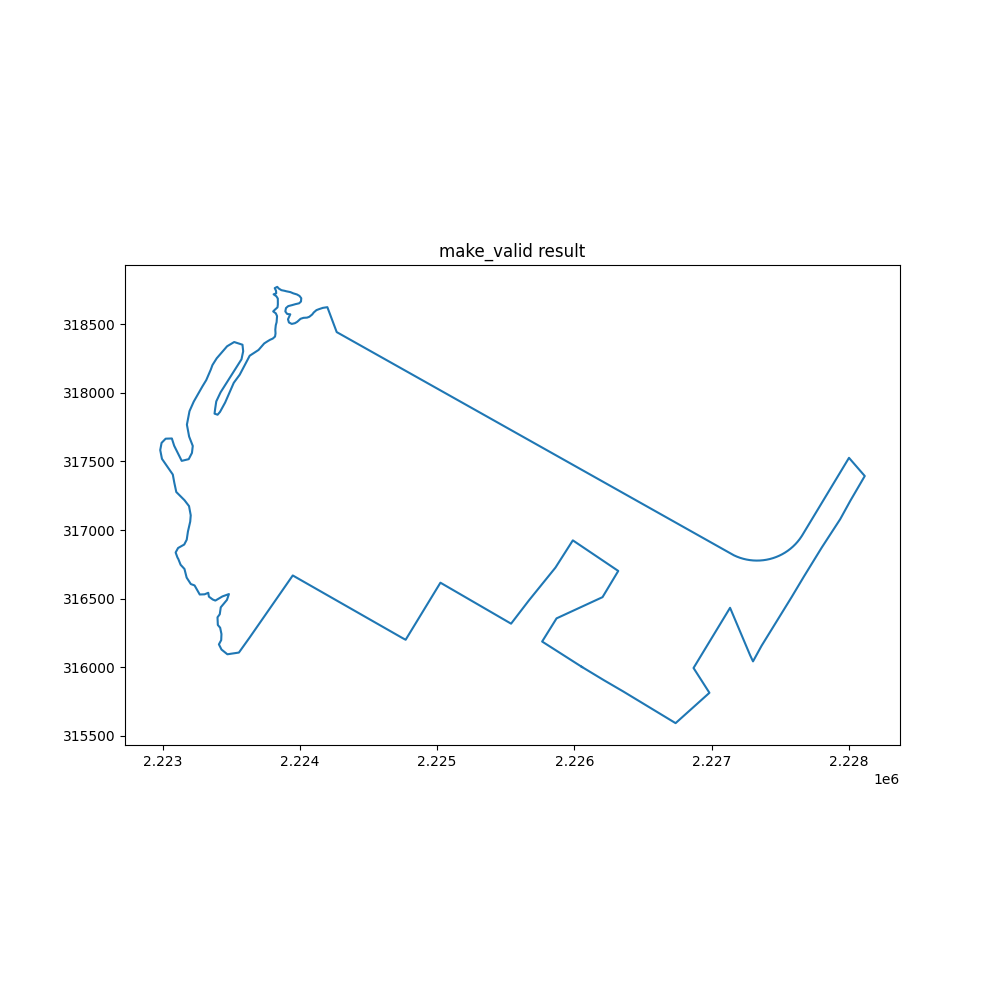

0 False Polygon 149.06213263168118


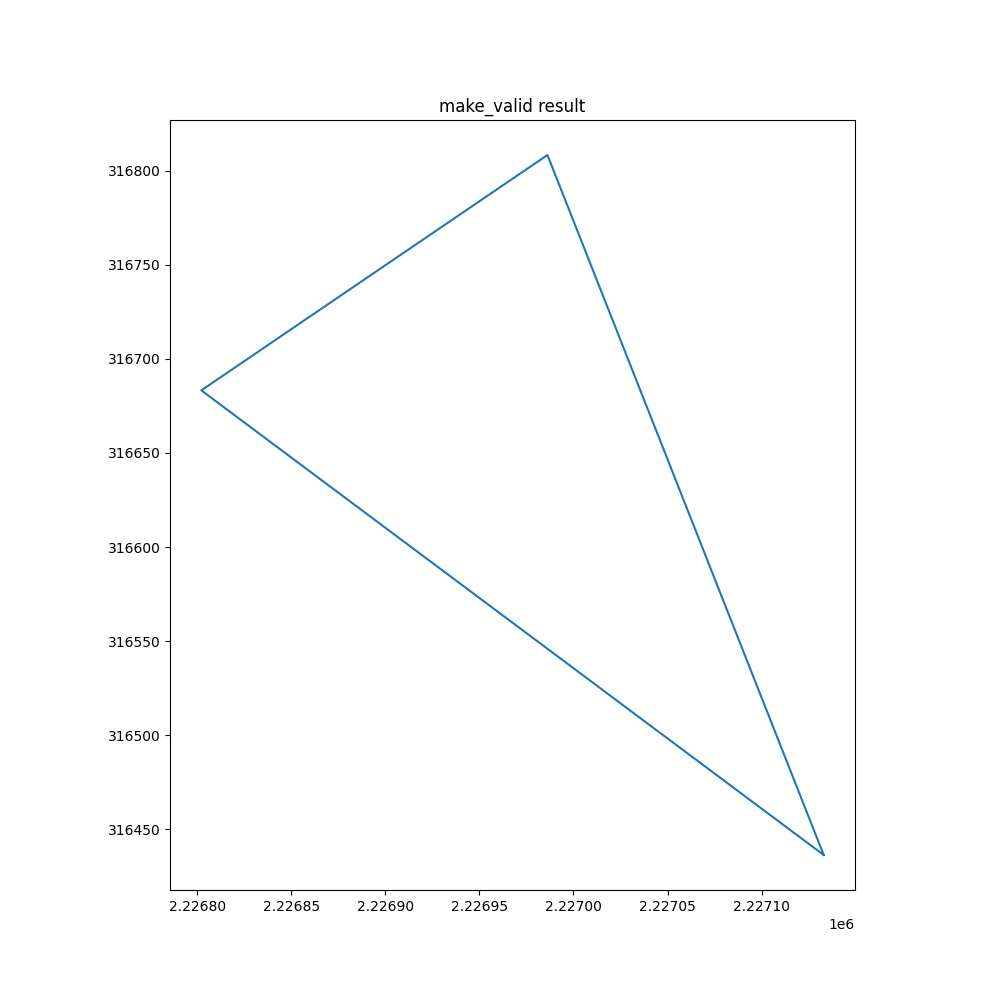

1 True Polygon 0.996701553811286


150.05883418549246

In [13]:
from shapely import make_valid
from shapely.geometry import Polygon

areas = []

for i, ring in enumerate(feature["geometry"]["rings"]):
    polygon = Polygon(ring)

    repaired = make_valid(polygon)

    x, y = repaired.exterior.xy

    plt.figure(figsize=(10, 10))
    plt.plot(x, y)
    plt.gca().set_aspect("equal")
    plt.title("make_valid result")
    plt.show()

    print(
        i,
        polygon.is_valid,
        repaired.geom_type,
        repaired.area / 43_560,
    )

    areas.append(repaired.area)

sum(areas) / 43_560